# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

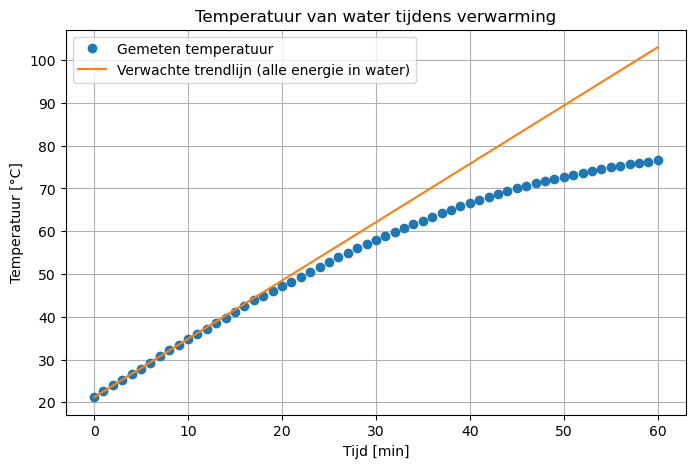

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ===============================
# Stap 1: Data inlezen
# ===============================
data = np.loadtxt("tempmetingen.csv", delimiter=";", skiprows = 1)  # Zorg dat CSV 2 kolommen heeft: tijd[min], temp[°C]
tijd = data[:,0]
temp_meet = data[:,1]

# ===============================
# Gegevens van de maatbeker en water
# ===============================
m_beker = 820.8  # g
m_start = 1292.9  # g
m_eind = 1274.9  # g

m_water_start = m_start - m_beker
m_water_eind = m_eind - m_beker
delta_m_water = m_water_start - m_water_eind  # verdampt water (g)

# Specifieke warmtecapaciteit van water
c_water = 4.18  # J/g°C

# ===============================
# Stap 2: Theoretische temperatuurverhoging
# ===============================
# Aangenomen dat alle toegevoerde energie in het water gaat:
# Energie toegevoegd = m_water_start * c * delta_T
# We passen curve_fit toe op een eenvoudige lineaire benadering (als verwarming constant vermogen levert)

# Functie: lineaire verhoging in tijd
def lineair(t, P_eff):
    # P_eff is effectief vermogen in J/min
    return temp_meet[0] + (P_eff / (m_water_start * c_water)) * t

# Curve fit: vind het effectieve vermogen P_eff over de eerste 10 meetpunten
popt, _ = curve_fit(lineair, tijd[:10], temp_meet[:10])
P_eff = popt[0]

# Theoretische trendlijn
temp_trend = lineair(tijd, P_eff)

# ===============================
# Stap 3: Plotten
# ===============================
plt.figure(figsize=(8,5))
plt.plot(tijd, temp_meet, 'o', label="Gemeten temperatuur")
plt.plot(tijd, temp_trend, '-', label="Verwachte trendlijn (alle energie in water)")
plt.xlabel("Tijd [min]")
plt.ylabel("Temperatuur [°C]")
plt.title("Temperatuur van water tijdens verwarming")
plt.legend()
plt.grid(True)
plt.show()





Als benadering van de verdampings-energie nemen we de bekende waarde bij 373,15 K: 2260 kJ/kg.

In [13]:
damp_ener = 2260e3 #J/kg
E_tot = P_eff * tijd[len(tijd)-1] #J
ener_verdamp = damp_ener * (delta_m_water/1000) #J
ener_verdamp_echt = E_tot - c_water * (0.5 *(m_water_start + m_water_eind)) * (max(temp_meet)-min(temp_meet)) #J

print("De totale toegevoegde energie is: ",E_tot,"J")
print("De hoeveelheid energie die het gekost zou hebben om ",delta_m_water,"g water te verdampen is: ",ener_verdamp,"J")
print("De hoeveelheid energie die het werkelijk gekost heeft om  ",delta_m_water,"g water te verdampen is: ",ener_verdamp_echt,"J")
print("Het verschil tussen de theoretische en werkelijke hoeveelheid energie is: ",ener_verdamp_echt - ener_verdamp,"J")

De totale toegevoegde energie is:  161443.09281073097 J
De hoeveelheid energie die het gekost zou hebben om  18.0 g water te verdampen is:  40680.0 J
De hoeveelheid energie die het werkelijk gekost heeft om   18.0 g water te verdampen is:  54202.09961073096 J
Het verschil tussen de theoretische en werkelijke hoeveelheid energie is:  13522.099610730962 J


Om het thermodynamisch beter te kunnen onderzoeken:
1. Nauwkeuriger en meer meten
- Gebruik een elektrisch vermogen-meter om exact te meten hoeveel energie het verwarmingselement levert in J/s (of W).
- Integreer het vermogen in de tijd zodat je de werkelijke totale toegevoerde energie kent, in plaats van dit af te leiden uit de temperatuurcurve.
- Noteer het gewicht op meerdere tijdstippen in plaats van alleen begin en eind, zodat je de verdamping in de tijd kunt volgen.
2. Minimaliseer warmteverlies naar de omgeving
- Gebruik een geïsoleerde maatbeker (bijvoorbeeld dubbelwandig of met isolatiemateriaal).
- Meet de omgevingstemperatuur en pas een correctie toe voor convectie- en stralingsverliezen.
3. Alle factoren meenemen
- Neem ook de warmtecapaciteit van het bekerglas en de instrumenten mee